# Multi-event history -> single catalog-continuation forecast (California polygon)

Core differences from the single-event waiting-time notebook:

1. **History is a `pandas.DataFrame` of multiple events** (not a single dict); the ETAS
   intensity sums the triggering kernel over all parents.
2. **One forecast**, not many Monte-Carlo realizations: a single *catalog continuation* over a
   fixed future window starting right after the latest history event.

We keep the **ETAS vs Ogata-thinning** comparison. The thinning here is a *branching* temporal-thinning continuation (each generated event becomes a parent), so it is the apples-to-apples counterpart of `simulate_catalog_continuation`.

In [1]:
from typing import TypedDict
import datetime as dt

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pyproj
import scipy
import shapely
import etas.mc_b_est as mc_b_est
import etas.utility_functions as utility_functions
import etas.simulation as simulation
from etas.inversion import polygon_surface, haversine
from matplotlib import colors
from matplotlib.path import Path as MplPath
from scipy.optimize import root_scalar
from shapely.geometry import MultiPoint, MultiPolygon, Point, Polygon
from shapely.ops import voronoi_diagram
from shapely.prepared import prep
from tqdm.auto import tqdm



%matplotlib inline


2026-06-25 16:43:22.807396: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-25 16:43:22.841512: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-25 16:43:22.841548: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-25 16:43:22.842714: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-25 16:43:22.848584: I tensorflow/core/platform/cpu_feature_guar

2026-06-25 16:43:24,900 - DEBUG - Loaded backend inline version unknown.


In [2]:
EARTH_RADIUS_KM = utility_functions.EARTH_RADIUS_KM


In [3]:
# Nodes per axis for A_h's parent-centered refined quadrature (log_rhs, thinning, saved CSV tag).
A_H_RESOLUTION = 500


class History(TypedDict):
    """Parent event in ETAS catalog convention: x=longitude, y=latitude."""

    m: float
    x: float  # longitude (degrees)
    y: float  # latitude (degrees)
    t: float


class EtasParams(TypedDict):
    mu: float
    k0: float
    a: float
    m_c: float
    d: float
    gamma: float
    rho: float
    c: float
    tau: float
    omega: float


def polygon_lat_lon_arrays(poly: Polygon) -> tuple[np.ndarray, np.ndarray]:
    """Return (lat, lon) arrays from polygon vertices in ETAS order (x=lat, y=lon)."""
    coords = np.asarray(poly.exterior.coords)
    return coords[:, 0], coords[:, 1]


def plot_polygon_map(ax, poly: Polygon, **plot_kwargs):
    """Plot an ETAS polygon on a map axis where matplotlib x=lon, y=lat."""
    lats, lons = polygon_lat_lon_arrays(poly)
    ax.plot(lons, lats, **plot_kwargs)


def a_h(
    lat: float,
    lon: float,
    H: History,
    params: EtasParams,
):
    """Spatial triggering kernel at (lat, lon) from history event H."""
    dist_sq_km2 = utility_functions.spatial_distance_squared_km2(
        lat, lon, H["y"], H["x"]
    )
    K = params["k0"] * np.exp(params["a"] * (H["m"] - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (H["m"] - params["m_c"]))
    return K / (dist_sq_km2 + C) ** (1 + params["rho"])


_A_H_CACHE: dict = {}


def A_h(
    poly: Polygon,
    H: History,
    params: EtasParams,
    resolution: int = 500,
    stretch: float = 3.5,
) -> float:
    """Integrate a_h over poly in km^2 with a grid refined around the parent.

    The spatial kernel is sharply peaked (half-width ~sqrt(C), only a few km), so a
    uniform grid over a large polygon's bounding box badly under-resolves the spike
    and underestimates the integral. Here the quadrature nodes are centered on the
    parent H and concentrated near it (``stretch`` > 1 packs nodes toward r=0), then
    clipped to the polygon. The result does not depend on t and callers (thinning,
    log_rhs) request it repeatedly with identical arguments, so it is cached.

    Polygon vertices follow ETAS inversion convention: Shapely (x, y) = (lat, lon).
    """
    min_lat, min_lon, max_lat, max_lon = poly.bounds
    if min_lat == max_lat or min_lon == max_lon:
        return 0.0

    key = (
        poly.wkt,
        H["m"], H["x"], H["y"],
        params["k0"], params["a"], params["d"],
        params["gamma"], params["rho"], params["m_c"],
        resolution, stretch,
    )
    cached = _A_H_CACHE.get(key)
    if cached is not None:
        return cached

    lat0, lon0 = H["y"], H["x"]
    km_per_lat, km_per_lon = utility_functions.km_per_degree_at_latitude(lat0)

    # Extent (km) from the parent out to the farthest bounding-box edge per axis.
    ext_y = max(abs(max_lat - lat0), abs(lat0 - min_lat)) * km_per_lat
    ext_x = max(abs(max_lon - lon0), abs(lon0 - min_lon)) * km_per_lon

    # Nodes packed near the parent (u**stretch), giving fine spacing where the kernel lives.
    u = np.linspace(-1.0, 1.0, resolution)
    sx = np.sign(u) * np.abs(u) ** stretch * ext_x
    sy = np.sign(u) * np.abs(u) ** stretch * ext_y
    SX, SY = np.meshgrid(sx, sy)
    WX, WY = np.meshgrid(np.gradient(sx), np.gradient(sy))
    dA_km2 = np.abs(WX * WY)

    LAT = lat0 + SY / km_per_lat
    LON = lon0 + SX / km_per_lon

    mask = MplPath(poly.exterior.coords).contains_points(
        np.column_stack((LAT.ravel(), LON.ravel()))
    ).reshape(LAT.shape)

    K = params["k0"] * np.exp(params["a"] * (H["m"] - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (H["m"] - params["m_c"]))
    dist_sq_km2 = utility_functions.spatial_distance_squared_km2(
        LAT.ravel(), LON.ravel(), H["y"], H["x"]
    ).reshape(LAT.shape)
    kernel = K / (dist_sq_km2 + C) ** (1 + params["rho"])

    val = float(np.sum((kernel * dA_km2)[mask]))
    _A_H_CACHE[key] = val
    return val


def polygon_area(polygon: Polygon) -> float:
    geod = pyproj.Geod(ellps="WGS84")
    # ETAS convention stores Shapely (x, y) = (lat, lon); pyproj wants (lon, lat).
    lon_lat = Polygon([(lon, lat) for lat, lon in polygon.exterior.coords])
    area_m2, _ = geod.geometry_area_perimeter(lon_lat)
    return abs(area_m2) / 1e6


def g(
    t: float,
    H : History,
    params: EtasParams,
    ):
    return np.exp(-(t - H['t']) / params['tau']) / (t - H['t'] + params['c'])**(1+params['omega'])


def etas_rate_at_latlon(
    lat: float,
    lon: float,
    t: float,
    H : History,
    params: EtasParams,
    ):
    return params['mu'] + a_h(lat, lon, H, params) * g(t, H, params)


def etas_rate_space_integrated(t, S, polygon, H, params, resolution: int = 50):
    return params['mu']*S +A_h(polygon, H, params, resolution) * g(t, H, params)


def unreg_gamma_old(a, x):
    return scipy.special.gammaincc(a, x) * scipy.special.gamma(a)


def unreg_gamma(a, x):
    """
    Computes the upper incomplete gamma function Gamma(a, x).
    Uses the recurrence relation to handle negative 'a' (e.g., a = -omega).
    """
    if a > 0:
        return scipy.special.gammaincc(a, x) * scipy.special.gamma(a)

    elif -1 < a < 0:
        # Shift the parameter to a+1 > 0
        a_plus_1 = a + 1.0
        gamma_a_plus_1 = scipy.special.gammaincc(a_plus_1, x) * scipy.special.gamma(a_plus_1)
        return (gamma_a_plus_1 - (x**a) * np.exp(-x)) / a
    else:
        raise ValueError("Parameter 'a' is out of bounds for standard ETAS omega values.")


# ----- multi-event helpers: history is a DataFrame; intensity sums over all parents -----

def to_history_dict(row) -> History:
    """One catalog row -> single-event History dict (ETAS coords: x=lon, y=lat)."""
    return {
        "m": float(row["m"]),
        "x": float(row["x"]),
        "y": float(row["y"]),
        "t": float(row["t"]),
    }


def lambda_s_total(t, events, poly, params, resolution: int = A_H_RESOLUTION) -> float:
    """Space-integrated temporal intensity at t: mu*area + sum_i A_h(poly, H_i) * g(t, H_i).

    Sums over every parent event with t_i <= t (history plus already-generated aftershocks),
    so it is the self-exciting (Hawkes/ETAS) intensity used for branching thinning.
    """
    rate = params["mu"] * polygon_area(poly)
    for H in events:
        if H["t"] <= t:
            rate += A_h(poly, H, params, resolution) * g(t, H, params)
    return rate


def parent_weights(t, events, poly, params, resolution: int = A_H_RESOLUTION):
    """Probabilities for the parent of an event at t: one per active event (t_i < t), background last."""
    contribs = [
        (A_h(poly, H, params, resolution) * g(t, H, params)) if H["t"] < t else 0.0
        for H in events
    ]
    contribs.append(params["mu"] * polygon_area(poly))  # background as the final option
    w = np.asarray(contribs, dtype=float)
    return w / w.sum()


def sample_background_location(poly: Polygon):
    """Uniform (lat, lon) inside the polygon via rejection sampling (poly coords are (lat, lon))."""
    min_lat, min_lon, max_lat, max_lon = poly.bounds
    while True:
        lat = np.random.uniform(min_lat, max_lat)
        lon = np.random.uniform(min_lon, max_lon)
        if poly.contains(Point(lat, lon)):
            return lat, lon


def sample_aftershock_location(H: History, params: EtasParams):
    """Isotropic aftershock (lat, lon) around parent H using the ETAS radial kernel."""
    r = simulation.simulate_aftershock_radius(
        params["log10_d"], params["gamma"], params["rho"], [H["m"]], params["m_c"]
    )[0]
    angle = np.random.uniform(0, 2 * np.pi)
    km_per_lat, km_per_lon = utility_functions.km_per_degree_at_latitude(H["y"])
    lat = H["y"] + (r * np.cos(angle)) / km_per_lat
    lon = H["x"] + (r * np.sin(angle)) / km_per_lon
    return float(lat), float(lon)

def filter_catalog_to_polygon(cat: pd.DataFrame, poly: Polygon) -> pd.DataFrame:
    """Keep only rows whose (y=lat, x=lon) intersect poly — same geometry as ETAS filter_polygon."""
    if cat.empty:
        return cat
    gdf = gpd.GeoDataFrame(cat, geometry=gpd.points_from_xy(cat["y"], cat["x"]))
    return gdf[gdf.intersects(poly)].drop(columns="geometry").reset_index(drop=True)



In [4]:
THETA_0 = {
    "log10_mu": -5.8,
    "log10_k0": -2.6,
    "a": 1.8,
    "log10_c": -2.5,
    "omega": -0.02,
    "log10_tau": 3.5,
    "log10_d": -0.85,
    "gamma": 1.3,
    "rho": 0.66,
    "m_c": 3.5,
}

for key in list(THETA_0.keys()):
    if key.startswith('log10_'):
        xx = key.replace('log10_', '')
        if xx not in THETA_0:
            THETA_0[xx] = 10 ** THETA_0[key]


THETA_0


{'log10_mu': -5.8,
 'log10_k0': -2.6,
 'a': 1.8,
 'log10_c': -2.5,
 'omega': -0.02,
 'log10_tau': 3.5,
 'log10_d': -0.85,
 'gamma': 1.3,
 'rho': 0.66,
 'm_c': 3.5,
 'mu': 1.584893192461114e-06,
 'k0': 0.0025118864315095794,
 'c': 0.0031622776601683794,
 'tau': 3162.2776601683795,
 'd': 0.14125375446227545}

## History: multiple events (DataFrame)

In [5]:
# Multiple history (auxiliary) events as a DataFrame. ETAS coords: x = longitude, y = latitude.
# Edit these rows to change the history sequence; all events must lie inside the polygon.
history_events = [
    # (time,                  magnitude, x = lon,  y = lat)
    ("2006-12-20 00:00:00",   5.2,       -119.5,    37.6),
    ("2006-12-25 12:00:00",   4.8,       -120.3,    38.2),
    ("2006-12-29 00:00:00",   6.5,       -120.0,    38.0),
]

history_df = pd.DataFrame(history_events, columns=["time", "m", "x", "y"])
history_df["time"] = pd.to_datetime(history_df["time"])
history_df["t"] = (history_df["time"] - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
history_df = history_df.sort_values("t").reset_index(drop=True)

# Aliases expected by the classic ETAS simulator.
history_df["latitude"] = history_df["y"]
history_df["longitude"] = history_df["x"]
history_df["magnitude"] = history_df["m"]

latest_history_time = history_df["time"].max()
latest_history_t = float(history_df["t"].max())
print(f"{len(history_df)} history events; latest at {latest_history_time}")
history_df


3 history events; latest at 2006-12-29 00:00:00


,time,m,x,y,t,latitude,longitude,magnitude
0,2006-12-20 00:00:00,5.2,-119.5,37.6,13502.0,37.6,-119.5,5.2
1,2006-12-25 12:00:00,4.8,-120.3,38.2,13507.5,38.2,-120.3,4.8
2,2006-12-29 00:00:00,6.5,-120.0,38.0,13511.0,38.0,-120.0,6.5


## Define domain area

In [6]:
SHAPE_COORDS = [
    [43.5, -125.7],
    [43.5, -118.5],
    [39.7, -118.5],
    [36.1, -113.6],
    [34.6, -112.6],
    [34.3, -112.6],
    [32.7, -113.1],
    [31.8, -113.2],
    [31.2, -114.5],
    [31.0, -117.1],
    [31.1, -117.4],
    [31.5, -118.3],
    [32.4, -118.8],
    [33.3, -121.3],
    [34.0, -122.0],
    [37.5, -124.3],
    [40.0, -125.9],
    [40.5, -125.9],
    [43.0, -125.7],
    [43.5, -125.7]
    ]


In [7]:
polygon = Polygon(SHAPE_COORDS)
polygon.exterior.xy


(array('d', [43.5, 43.5, 39.7, 36.1, 34.6, 34.3, 32.7, 31.8, 31.2, 31.0, 31.1, 31.5, 32.4, 33.3, 34.0, 37.5, 40.0, 40.5, 43.0, 43.5]),
 array('d', [-125.7, -118.5, -118.5, -113.6, -112.6, -112.6, -113.1, -113.2, -114.5, -117.1, -117.4, -118.3, -118.8, -121.3, -122.0, -124.3, -125.9, -125.9, -125.7, -125.7]))

2026-06-25 16:43:24,957 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-06-25 16:43:24,957 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-25 16:43:24,958 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-25 16:43:24,958 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sa

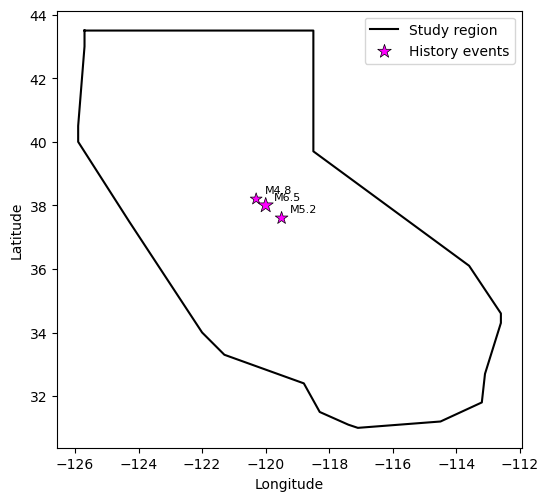

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_polygon_map(ax, polygon, color="black", label="Study region")
ax.scatter(
    history_df["x"],
    history_df["y"],
    s=80 + 30 * (history_df["m"] - history_df["m"].min()),
    c="magenta",
    marker="*",
    edgecolors="black",
    linewidths=0.5,
    zorder=6,
    label="History events",
)
for _, row in history_df.iterrows():
    ax.annotate(f"M{row['m']}", (row["x"], row["y"]), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.legend()
plt.show()


## Forecast window settings

In [9]:
# --- single catalog-continuation forecast settings (edit these) ---
# Forecast starts right after the latest history event and runs for FORECAST_DAYS.
FORECAST_DAYS = 30.0
FORECAST_START = latest_history_time                     # time T: window start (= last history event)
FORECAST_END = FORECAST_START + pd.Timedelta(days=FORECAST_DAYS)

forecast_start_t = latest_history_t                      # window start in days-since-epoch
forecast_end_t = forecast_start_t + FORECAST_DAYS

# magnitude distribution (Gutenberg-Richter b = 1 => beta = ln 10)
BETA_MAIN = np.log(10)
MC = THETA_0["m_c"]

# single realization (no Monte-Carlo recreations); fix the seed for reproducibility
SEED = 0

print(f"Forecast window: {FORECAST_START}  ->  {FORECAST_END}  ({FORECAST_DAYS:g} days)")


Forecast window: 2006-12-29 00:00:00  ->  2007-01-28 00:00:00  (30 days)


## Method A - Classic ETAS catalog continuation (single run)

In [10]:
# Classic ETAS catalog continuation, run ONCE over the forecast window.
theta = {
    key: THETA_0[key]
    for key in ["log10_mu", "log10_k0", "a", "log10_c", "omega", "log10_tau", "log10_d", "gamma", "rho"]
}


def _to_naive_utc(ts):
    return pd.to_datetime(ts, utc=True).tz_convert(None)


auxiliary_catalog = history_df[["time", "latitude", "longitude", "magnitude"]].copy()
auxiliary_catalog["time"] = pd.to_datetime(auxiliary_catalog["time"], utc=True).dt.tz_convert(None)
auxiliary_catalog["xi_plus_1"] = 1.0

auxiliary_start = auxiliary_catalog["time"].min()
forecast_start_dt = _to_naive_utc(FORECAST_START)
forecast_end_dt = _to_naive_utc(FORECAST_END)

np.random.seed(SEED)
etas_cont = simulation.simulate_catalog_continuation(
    auxiliary_catalog=auxiliary_catalog,
    auxiliary_start=auxiliary_start,
    auxiliary_end=forecast_start_dt,
    polygon=polygon,
    simulation_end=forecast_end_dt,
    parameters=dict(theta),
    mc=float(MC),
    beta_main=BETA_MAIN,
    filter_polygon=True,  # default ETAS: trim after simulation
    magnitude_generator=mc_b_est.simulate_magnitudes,
)

etas_cont["time"] = pd.to_datetime(etas_cont["time"], utc=True).dt.tz_convert(None)
etas_catalog = (
    etas_cont.loc[etas_cont["time"] > forecast_start_dt].sort_values("time").reset_index(drop=True)
)
etas_catalog["t"] = (etas_catalog["time"] - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
etas_catalog["dt_days"] = etas_catalog["t"] - forecast_start_t
# unified (x = lon, y = lat) columns for plotting alongside the thinning catalog
etas_catalog["x"] = etas_catalog["longitude"]
etas_catalog["y"] = etas_catalog["latitude"]
etas_catalog["m"] = etas_catalog["magnitude"]
if "is_background" in etas_catalog.columns:
    etas_catalog["event_source"] = np.where(etas_catalog["is_background"].astype(bool), "background", "triggered")

print(f"ETAS continuation: {len(etas_catalog)} events in the {FORECAST_DAYS:g}-day window")
etas_catalog.head()


2026-06-25 16:43:25,524 - INFO -   number of background events needed: 47
2026-06-25 16:43:25,525 - INFO -   generating 96 to throw away those outside the polygon
2026-06-25 16:43:25,530 - DEBUG - number of induced events: 0
2026-06-25 16:43:25,533 - DEBUG - number of background events: 47
2026-06-25 16:43:25,534 - DEBUG - number of auxiliary events: 3
2026-06-25 16:43:25,534 - DEBUG - generation 0
2026-06-25 16:43:25,536 - DEBUG - number of events with aftershocks: 32
2026-06-25 16:43:25,545 - DEBUG - number of aftershocks: 34
2026-06-25 16:43:25,545 - DEBUG - their number of aftershocks should be:33
2026-06-25 16:43:25,547 - DEBUG - generation 1
2026-06-25 16:43:25,549 - DEBUG - number of events with aftershocks: 19
2026-06-25 16:43:25,557 - DEBUG - number of aftershocks: 20
2026-06-25 16:43:25,557 - DEBUG - their number of aftershocks should be:15
2026-06-25 16:43:25,558 - DEBUG - generation 2
2026-06-25 16:43:25,560 - DEBUG - number of events with aftershocks: 9
2026-06-25 16:43:25

,angle,degree_lat,degree_lon,evt_id,expected_n_aftershocks,gen_0_parent,generation,is_background,latitude,longitude,...,radius,time,time_delta,xi_plus_1,t,dt_days,x,y,m,event_source
0,5.793797,111.318845,87.720025,NaN,0.624107,3,1,False,38.022999,-120.015545,...,2.900727,2006-12-29 00:06:24.140359863,0.004446,1.0,13511.004446,0.004446,-120.015545,38.022999,3.562212,triggered
1,2.341612,111.318845,87.720025,NaN,1.435941,3,1,False,37.971879,-119.963257,...,4.493098,2006-12-29 00:17:36.043924652,0.012223,1.0,13511.012223,0.012223,-119.963257,37.971879,4.446771,triggered
2,0.120153,111.318845,87.753652,NaN,0.800364,3,2,False,37.981100,-119.961845,...,1.033999,2006-12-29 00:24:01.937112142,0.004466,1.0,13511.016689,0.016689,-119.961845,37.981100,3.826273,triggered
3,5.295323,111.318845,87.753652,NaN,1.096541,3,2,False,37.975640,-119.970493,...,0.760633,2006-12-29 00:38:40.697190211,0.014637,1.0,13511.026860,0.026860,-119.970493,37.975640,4.160508,triggered
4,3.333464,111.318845,87.720025,NaN,0.873318,3,1,False,37.871980,-120.031560,...,14.517416,2006-12-29 02:15:03.166585704,0.093787,1.0,13511.093787,0.093787,-120.031560,37.871980,3.918877,triggered


## Method B - Ogata branching-thinning catalog continuation

Same model, generated by thinning the space-integrated intensity `lambda_s(t) = mu*area + sum_i A_h(poly, H_i) * g(t, H_i)` and letting each event branch.

In [11]:
def thinning_next_event_time(intensity_fn, t0, t_end):
    """Ogata (1981) thinning for the next event time in (t0, t_end].

    Returns the next event time, or None if the next event would fall after t_end.
    Valid because lambda_s_total is non-increasing between events, so intensity_fn(t0)
    upper-bounds the intensity until the next accepted event.
    """
    bound = intensity_fn(t0)
    t = t0
    while True:
        if bound <= 0:
            return None
        t += np.random.exponential(1.0 / bound)
        if t > t_end:
            return None
        cand = intensity_fn(t)
        if np.random.uniform() < cand / bound:
            return t
        bound = cand


def simulate_thinning_continuation(
    history_df,
    poly,
    params,
    t_start,
    t_end,
    beta,
    mc,
    resolution: int = A_H_RESOLUTION,
    filter_polygon: bool = True,
):
    """Branching temporal-thinning catalog continuation over (t_start, t_end].

    Mirrors classic ETAS continuation: the history events seed the intensity, each newly
    generated event becomes a parent (branching), times come from Ogata thinning of the
    space-integrated intensity, locations from the per-parent radial kernel (or uniform
    background), and magnitudes from the Gutenberg-Richter generator.

    With filter_polygon=True (default, matching simulate_catalog_continuation): every
    generated event enters the branching state (even if outside the polygon), but only
    in-polygon events are returned in the forecast catalog.
    """
    events = [to_history_dict(row) for _, row in history_df.iterrows()]
    forecast = []
    intensity = lambda t: lambda_s_total(t, events, poly, params, resolution)

    t = t_start
    while True:
        t_next = thinning_next_event_time(intensity, t, t_end)
        if t_next is None:
            break

        w = parent_weights(t_next, events, poly, params, resolution)
        idx = np.random.choice(len(w), p=w)
        if idx == len(w) - 1:
            lat, lon = sample_background_location(poly)
            source = "background"
        else:
            lat, lon = sample_aftershock_location(events[idx], params)
            source = "triggered"

        m = float(mc_b_est.simulate_magnitudes(1, beta, mc)[0])
        event = {"m": m, "x": float(lon), "y": float(lat), "t": float(t_next)}
        events.append(event)  # always branch (matches ETAS: outside events trigger too)
        forecast.append({**event, "event_source": source})
        t = t_next

    out = pd.DataFrame(forecast, columns=["t", "x", "y", "m", "event_source"])
    if filter_polygon:
        out = filter_catalog_to_polygon(out, poly)
    return out


In [12]:
# Ogata branching-thinning catalog continuation, run ONCE over the same window.
np.random.seed(SEED)
thinning_catalog = simulate_thinning_continuation(
    history_df,
    polygon,
    THETA_0,
    forecast_start_t,
    forecast_end_t,
    BETA_MAIN,
    MC,
)
thinning_catalog["dt_days"] = thinning_catalog["t"] - forecast_start_t
print(f"Thinning continuation: {len(thinning_catalog)} events in the {FORECAST_DAYS:g}-day window")
thinning_catalog.head()


Thinning continuation: 95 events in the 30-day window


,t,x,y,m,event_source,dt_days
0,13511.651343,-124.955220,42.569958,3.539591,background,0.651343
1,13513.451980,-119.954597,38.028350,4.757031,triggered,2.451980
2,13513.651408,-120.035377,37.967191,3.916726,triggered,2.651408
3,13513.955041,-117.032003,31.752818,3.982326,background,2.955041
4,13513.965935,-117.034303,31.748675,3.750729,triggered,2.965935


## Comparison: ETAS vs thinning

Each method is a **single** stochastic catalog, so exact overlap is not expected; the cumulative count, spatial spread, and magnitude-frequency should be statistically consistent.

In [ ]:
ETAS_COLOR = "seagreen"
THINNING_COLOR = "indianred"

fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))

# (1) cumulative count N(t) over the window
ax = axes[0]
for cat, color, label in [(etas_catalog, ETAS_COLOR, "ETAS"), (thinning_catalog, THINNING_COLOR, "Thinning")]:
    d = np.sort(cat["dt_days"].to_numpy())
    n = np.arange(1, d.size + 1)
    ax.step(np.concatenate(([0.0], d)), np.concatenate(([0], n)), where="post", color=color, lw=1.8,
            label=f"{label} (n={d.size})")
ax.set_xlabel("days since forecast start")
ax.set_ylabel("cumulative number of events")
ax.set_title("Cumulative count N(t)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

# (2) spatial map
ax = axes[1]
plot_polygon_map(ax, polygon, color="black", linewidth=1.5)
ax.scatter(history_df["x"], history_df["y"], marker="*", s=160, c="magenta",
           edgecolors="black", zorder=6, label="History")
ax.scatter(etas_catalog["x"], etas_catalog["y"], s=28, c=ETAS_COLOR, alpha=0.6,
           edgecolors="black", linewidths=0.3, zorder=4, label="ETAS")
ax.scatter(thinning_catalog["x"], thinning_catalog["y"], s=28, c=THINNING_COLOR, alpha=0.6,
           marker="^", edgecolors="black", linewidths=0.3, zorder=5, label="Thinning")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.set_title("Forecast event locations")
ax.legend(loc="upper right", fontsize=8)

# (3) magnitude-frequency (cumulative N >= m)
ax = axes[2]
for cat, color, label in [(etas_catalog, ETAS_COLOR, "ETAS"), (thinning_catalog, THINNING_COLOR, "Thinning")]:
    if len(cat):
        m_sorted = np.sort(cat["m"].to_numpy())
        n_ge = np.arange(len(m_sorted), 0, -1)
        ax.step(m_sorted, n_ge, where="post", color=color, lw=1.6, label=label)
ax.set_yscale("log")
ax.set_xlabel("magnitude")
ax.set_ylabel("N(>= m)")
ax.set_title("Magnitude-frequency")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

fig.suptitle(
    f"ETAS vs Ogata thinning - single catalog continuation "
    f"({len(history_df)} history events, {FORECAST_DAYS:g}-day window)",
    fontsize=13,
)
fig.tight_layout()
plt.show()

summary = pd.DataFrame(
    {
        "metric": ["events in window", "background", "triggered",
                   "median dt [days]", "max magnitude"],
        "ETAS": [
            len(etas_catalog),
            int((etas_catalog.get("event_source") == "background").sum()) if "event_source" in etas_catalog else np.nan,
            int((etas_catalog.get("event_source") == "triggered").sum()) if "event_source" in etas_catalog else np.nan,
            float(np.median(etas_catalog["dt_days"])) if len(etas_catalog) else np.nan,
            float(etas_catalog["m"].max()) if len(etas_catalog) else np.nan,
        ],
        "Thinning": [
            len(thinning_catalog),
            int((thinning_catalog["event_source"] == "background").sum()),
            int((thinning_catalog["event_source"] == "triggered").sum()),
            float(np.median(thinning_catalog["dt_days"])) if len(thinning_catalog) else np.nan,
            float(thinning_catalog["m"].max()) if len(thinning_catalog) else np.nan,
        ],
    }
).set_index("metric")
summary


2026-06-25 16:43:29,066 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
2026-06-25 16:43:29,066 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-25 16:43:29,067 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-25 16:43:29,067 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sa

## More comparisons: conditional intensity λ_s(t) and binned magnitude-frequency

- **Left:** the space-integrated conditional intensity `λ_s(t) = μ·area + Σ_i A_h(poly, H_i)·g(t, H_i)`. The black curve is the history-only driving rate; the coloured curves are each method's *realized* self-exciting intensity (history + that catalog's own events), so every event makes the rate jump up. Ticks at the bottom mark event times.
- **Right:** incremental (binned) magnitude-frequency with the Gutenberg–Richter expectation (dashed) scaled to each catalog's event count.

2026-06-25 16:53:32,794 - DEBUG - vmin 0.6233730731004408 vmax 273.2266394325237
2026-06-25 16:53:32,795 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04])
2026-06-25 16:53:32,799 - DEBUG - vmin 0.6233730731004408 vmax 273.2266394325237
2026-06-25 16:53:32,799 - DEBUG - ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04])
2026-06-25 16:53:32,799 - DEBUG - vmin 0.6233730731004408 vmax 273.2266394325237
2026-06-25 16:53:32,800 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04])
20

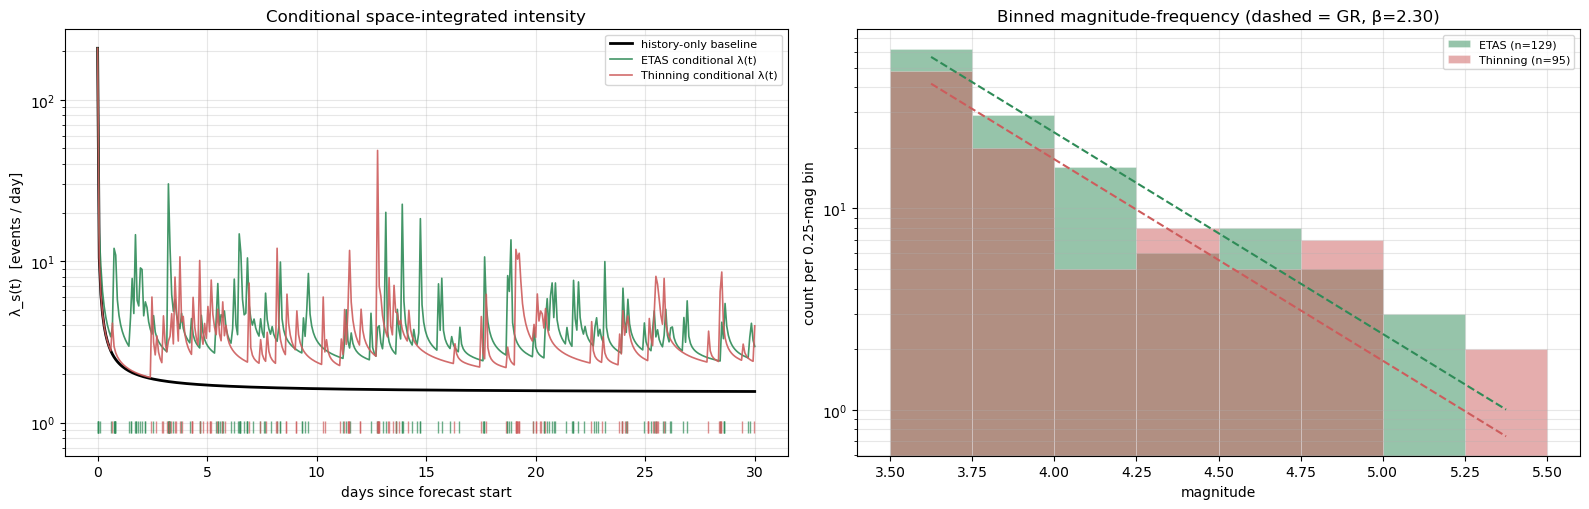

In [14]:
fig, (ax_t, ax_m) = plt.subplots(1, 2, figsize=(16, 5.2))

# ---------- (left) conditional space-integrated intensity lambda_s(t) ----------
t_grid = np.linspace(forecast_start_t, forecast_end_t, 400)
dt_grid = t_grid - forecast_start_t

hist_events = [to_history_dict(row) for _, row in history_df.iterrows()]
lam_hist = np.array([lambda_s_total(t, hist_events, polygon, THETA_0) for t in t_grid])
ax_t.plot(dt_grid, lam_hist, color="black", lw=2.0, label="history-only baseline")


def _events_from_catalog(cat):
    evs = list(hist_events)
    for _, r in cat.iterrows():
        evs.append({"m": float(r["m"]), "x": float(r["x"]), "y": float(r["y"]), "t": float(r["t"])})
    return evs


y_tick = max(lam_hist.min(), 1e-3)
for cat, color, label in [(etas_catalog, ETAS_COLOR, "ETAS"), (thinning_catalog, THINNING_COLOR, "Thinning")]:
    evs = _events_from_catalog(cat)
    lam = np.array([lambda_s_total(t, evs, polygon, THETA_0) for t in t_grid])
    ax_t.plot(dt_grid, lam, color=color, lw=1.2, alpha=0.9, label=f"{label} conditional λ(t)")
    if len(cat):
        ax_t.plot(cat["dt_days"], np.full(len(cat), y_tick * 0.6), "|", color=color, markersize=9, alpha=0.7)

ax_t.set_yscale("log")
ax_t.set_ylim(bottom=y_tick * 0.4)
ax_t.set_xlabel("days since forecast start")
ax_t.set_ylabel("λ_s(t)  [events / day]")
ax_t.set_title("Conditional space-integrated intensity")
ax_t.grid(True, which="both", alpha=0.3)
ax_t.legend(fontsize=8, loc="upper right")

# ---------- (right) incremental (binned) magnitude-frequency ----------
all_m = np.concatenate([etas_catalog["m"].to_numpy(), thinning_catalog["m"].to_numpy()])
m_hi = float(all_m.max()) if all_m.size else MC + 1.0
m_bins = np.arange(MC, m_hi + 0.25, 0.25)
centers = 0.5 * (m_bins[:-1] + m_bins[1:])

for cat, color, label in [(etas_catalog, ETAS_COLOR, "ETAS"), (thinning_catalog, THINNING_COLOR, "Thinning")]:
    if len(cat):
        ax_m.hist(cat["m"], bins=m_bins, color=color, alpha=0.5, edgecolor="white",
                  linewidth=0.4, label=f"{label} (n={len(cat)})")
        # Gutenberg-Richter expected count per bin, scaled to this catalog's size
        gr_counts = len(cat) * (
            np.exp(-BETA_MAIN * (m_bins[:-1] - MC)) - np.exp(-BETA_MAIN * (m_bins[1:] - MC))
        )
        ax_m.plot(centers, gr_counts, color=color, ls="--", lw=1.5)

ax_m.set_yscale("log")
ax_m.set_xlabel("magnitude")
ax_m.set_ylabel("count per 0.25-mag bin")
ax_m.set_title(f"Binned magnitude-frequency (dashed = GR, β={BETA_MAIN:.2f})")
ax_m.grid(True, which="both", alpha=0.3)
ax_m.legend(fontsize=8)

fig.tight_layout()
plt.show()


## Magnitude vs time + cumulative count (ETAS vs thinning)

Top: stem/scatter of event magnitude against time (days since forecast start), ETAS and thinning overlaid in their colour code with the history events marked. Bottom (shared x-axis): cumulative number of forecast events N(t).

/tmp/ipykernel_3627066/4065935951.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


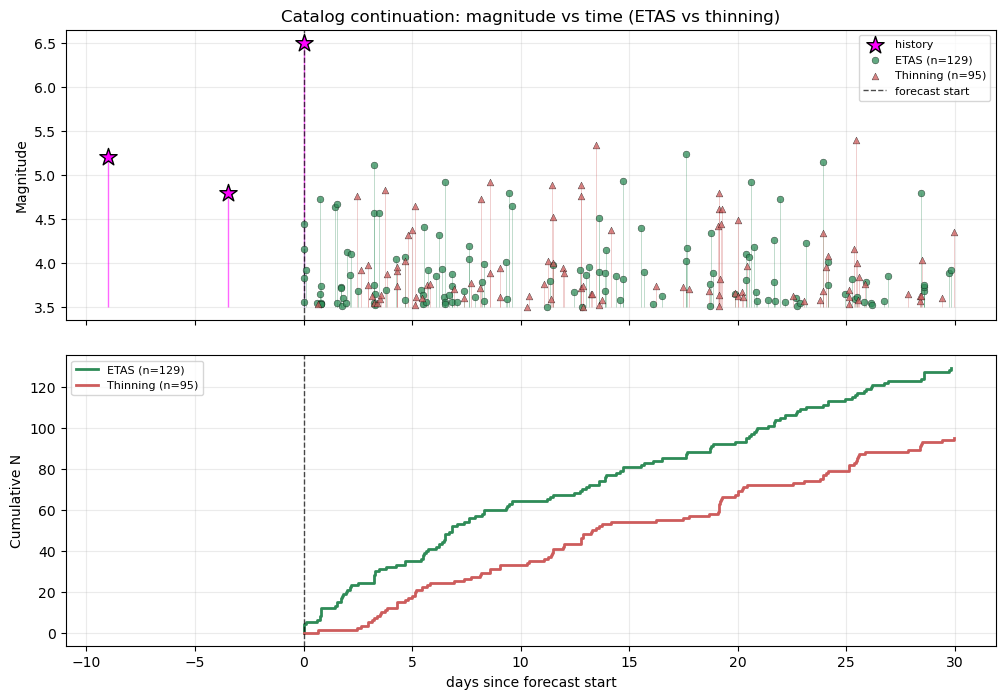

In [16]:
fig, (ax_mag, ax_cum) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"hspace": 0.12}
)

# --- top: magnitude vs time ---
hist_dt = history_df["t"].to_numpy() - forecast_start_t
ax_mag.vlines(hist_dt, MC, history_df["m"], color="magenta", lw=1.0, alpha=0.6)
ax_mag.scatter(hist_dt, history_df["m"], marker="*", s=170, c="magenta",
               edgecolors="black", zorder=6, label="history")

for cat, color, label, marker in [
    (etas_catalog, ETAS_COLOR, "ETAS", "o"),
    (thinning_catalog, THINNING_COLOR, "Thinning", "^"),
]:
    if len(cat):
        ax_mag.vlines(cat["dt_days"], MC, cat["m"], color=color, lw=0.6, alpha=0.35)
        ax_mag.scatter(cat["dt_days"], cat["m"], s=24, c=color, marker=marker, alpha=0.75,
                       edgecolors="black", linewidths=0.3, zorder=4, label=f"{label} (n={len(cat)})")

ax_mag.axvline(0.0, color="black", ls="--", lw=1.0, alpha=0.7, label="forecast start")
ax_mag.set_ylabel("Magnitude")
ax_mag.set_title("Catalog continuation: magnitude vs time (ETAS vs thinning)")
ax_mag.grid(True, alpha=0.25)
ax_mag.legend(loc="upper right", fontsize=8)

# --- bottom: cumulative number of events ---
for cat, color, label in [
    (etas_catalog, ETAS_COLOR, "ETAS"),
    (thinning_catalog, THINNING_COLOR, "Thinning"),
]:
    if len(cat):
        d = np.sort(cat["dt_days"].to_numpy())
        ax_cum.plot(np.concatenate(([0.0], d)), np.arange(0, d.size + 1),
                    drawstyle="steps-post", color=color, lw=2.0, label=f"{label} (n={d.size})")

ax_cum.axvline(0.0, color="black", ls="--", lw=1.0, alpha=0.7)
ax_cum.set_xlabel("days since forecast start")
ax_cum.set_ylabel("Cumulative N")
ax_cum.grid(True, alpha=0.25)
ax_cum.legend(loc="upper left", fontsize=8)

fig.tight_layout()
plt.show()


## Spatial map: history + forecast catalogs

California polygon with history events (magenta stars) and the ETAS / thinning forecast locations overlaid in their colour code. Marker size scales with magnitude.

2026-06-25 17:05:19,076 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=bold:stretch=normal:size=9.0.
2026-06-25 17:05:19,076 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
2026-06-25 17:05:19,076 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
2026-06-25 17:05:19,076 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu San

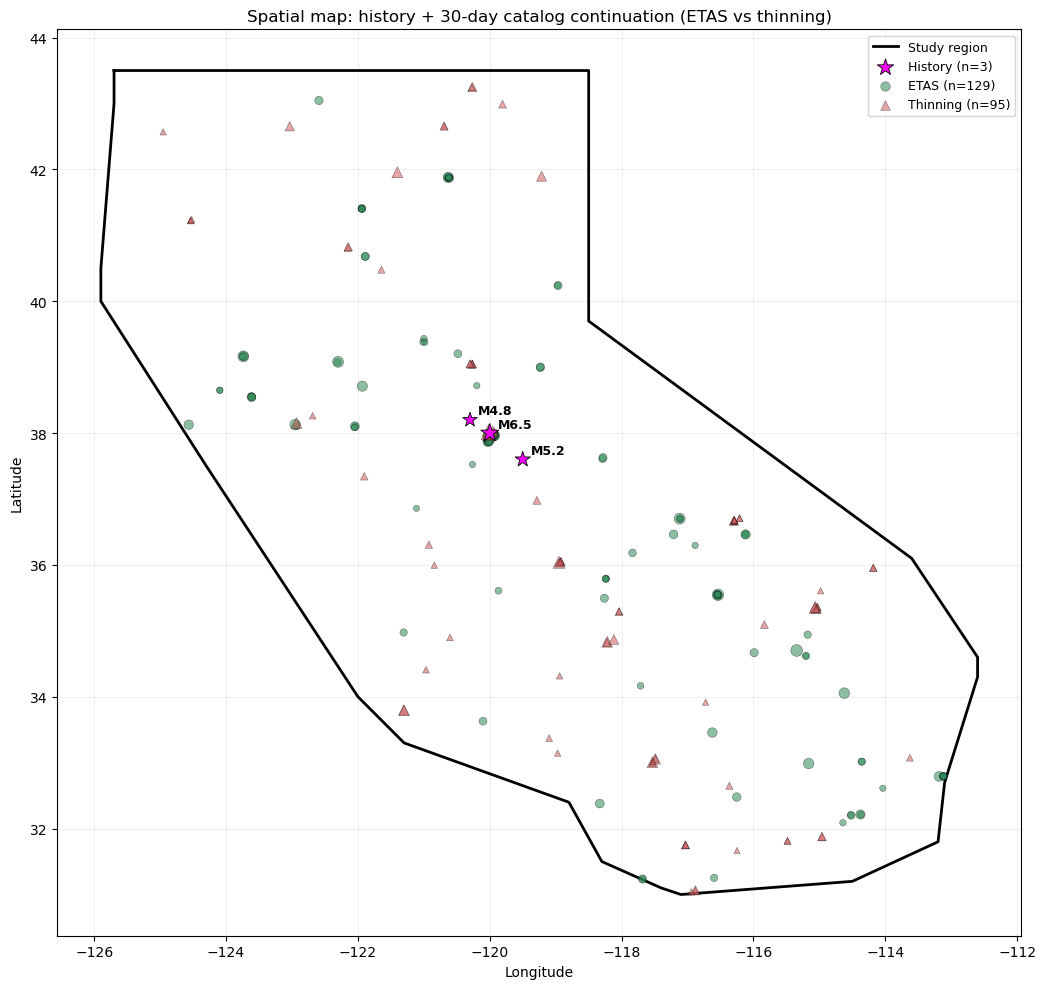

In [17]:
fig_map, ax = plt.subplots(figsize=(12, 10))

plot_polygon_map(ax, polygon, color="black", linewidth=2, label="Study region")

# history (auxiliary) events
ax.scatter(
    history_df["x"],
    history_df["y"],
    s=120 + 40 * (history_df["m"] - history_df["m"].min()),
    marker="*",
    c="magenta",
    edgecolors="black",
    linewidths=0.6,
    zorder=7,
    label=f"History (n={len(history_df)})",
)
for _, row in history_df.iterrows():
    ax.annotate(
        f"M{row['m']}",
        (row["x"], row["y"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=9,
        fontweight="bold",
    )

# forecast catalogs
for cat, color, label, marker in [
    (etas_catalog, ETAS_COLOR, "ETAS", "o"),
    (thinning_catalog, THINNING_COLOR, "Thinning", "^"),
]:
    if len(cat):
        sizes = 20 + 30 * (cat["m"] - MC)
        ax.scatter(
            cat["x"],
            cat["y"],
            s=sizes,
            c=color,
            marker=marker,
            alpha=0.55,
            edgecolors="black",
            linewidths=0.35,
            zorder=5,
            label=f"{label} (n={len(cat)})",
        )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.set_title(
    f"Spatial map: history + {FORECAST_DAYS:g}-day catalog continuation "
    f"(ETAS vs thinning)"
)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)
fig_map.tight_layout()
plt.show()
